> 20240414-开源证券-开源量化评论（91）：形态识别，均线的收敛与发散

# 前言

2022年以来, A 股市场持续处于震荡向下的态势, 市场主导风格不断切换, 投资者切身感知的赚钱效应处于历史低位水平。在宏观环境波诡云谲的当下, 传统的 定价范式开始被颠覆, 各种异象频发。在量化选股领域, 则体现为传统的基本面类因子有效性衰减明显, 捕捉市场投资者错误定价的价量因子开始成为焦点, 尤以深 度学习挖掘的高频价量因子为甚。但在聚光灯之外, 一种既有的投资风潮亦在重新 进入大众视野, 那便是$\mathrm{K}$线的形态研究。A 股投资者在持续被市场教育之后, 投资方法论开始去繁就简，返璞归真。

市场中的投资者关于个股$\mathrm{K}$线形态的研究,以往更多放在个股的择时上,但个股择时操作往往胜率较低且赔率不稳定。其次,大家在进行个股$\mathrm{K}$线形态识别时,  重心总是不自觉被放到价格均线之上, 但有效的信息并不局限于价格, 还有成交量、 换手率等多维度数据。针对上述两点弊端, 本篇报告中, 我们尝试将个股择时代表 的事件驱动策略转变为截面选股策略, 虽然在一定程度上降低了事件发生即调仓的 及时性, 但截面维度所拥有的样本广度, 能有效提升策略收益的稳定性。与此同时,  我们不仅从价格维度进行$\mathrm{K}$线形态识别,亦讨论了隐藏在主流视野之外的成交量、 成交额以及换手率均线在$\mathrm{K}$线形态识别上的作用。

本篇报告分为四个部分。第一部分, 我们从市场的主流认知出发, 首先论述了个股价格均线的收敛与发散形态对未来收益的预测能力差异, 发现价格均线收敛往往是个股股价变盘点的前奏。在价格均线的基础上, 我们引入了成交量均线, 使用成交量均线的收敛与发散形态来锚定当前个股股价位置的高低。第二部分, 我们对均线指标进行衍生, 测试了直接囊括价量信息的成交额均线收敛与发散的表现, 以 及便于不同个股在截面直接可比的换手率均线收敛与发散的预测效果。第三部分,  我们以历史表现最优的换手率均线收敛因子为例, 详细介绍了其在不同宽基指数中的增强表现。第四部分, 我们讨论了换手率收敛因子调仓频率的变化对结果的影响,以及在进行因子计算时, 均线的选取数量是否能够显著影响最终效果。

# 结论

**价量均线的收敛与发散形态能有效预测个股未来收益**

- 不同周期价格均线之间的发散是常态,而收敛通常仅出现在特定的窗口期。当不同周期价格均线趋于收敛时, 我们倾向于认为个股未来进行方向选择的概率提升, 即变盘点的前兆。
- 不同周期成交量均线的收敛发散衡量了市场上投资者交易意愿的变化。当长短期成交量水平趋于一致时, 往往是因为个股赚钱效应弱化, 导致投资者交易意愿下滑, 股价处于阶段底部的概率升高。

通过将价与量进行融合, 我们希望通过价格均线收敛与否来判断个股当前时刻是 否位于变盘点前夕，通过成交量均线收敛与否来判断个股当前所处位置的高低。

**另类指标的收敛与发散形态比常规价量更加有效**


# 价量均线的收敛与发散

如何定义股票价格均线的收敛与发散呢? 直观上来看, 不同周期均线两两之间 当前时刻的距离加总之和可以用来作为均线收敛和发散的程度, 当该值越小的时候,  表明越收敛, 反之, 则越发散。但距离加总会随着均线数量的增加提升计算复杂度,  为此我们使用当前时刻不同均线之间的标准差来进行简化操作。

### 价格的收敛与发散

不同周期价格均线之间的发散是常态, 而收敛通常仅出现在特定的窗口期。当 不同周期价格均线趋于收敛时, 往往代表市场上不同类型的投资者在个股上的持仓 成本逐渐趋同, 筹码分布更趋集中, 未来无论股价往上突破抑或往下下探, 此时个 股面临的阻力都相应下降。由于股价总是沿着阻力最小的方向运行, 我们倾向于认 为个股未来进行方向选择的概率提升, 即变盘点的前兆。

我们选取个股当日收盘价, 并计算不同周期下 (5、10、20、60、120 日) 的均 值, 计算 6 条均线之间在截面上的标准差。为使得因子值分布更接近正态分布, 我 们对结果进行取对数处理, 并通过取负操作使得因子值预测方向为正。为了避免价 格跳空现象, 我们使用后复权价格进行均线计算, 且在因子构建时未剔除截面上不 同个股价格数值的量纲差异。
$$\text{ factor } =  - \log \left( {1 + \operatorname{std}\left( {m{a}_{1},m{a}_{5},m{a}_{10},m{a}_{20},m{a}_{60},m{a}_{120}}\right) }\right)$$

factor为价格收敛因子 (Price Convergence Factor, PCF), 其中当日收盘价即为  $m{a}_{1}$ 。为便捷表述，下文存在中文名称与英文简写混用。

与研报不同的是我们并未对股票池去除ST及上述不如一年的剔除处理，也未对因子进行行业、市值的中性化处理。


In [1]:
import importlib
import sys
from pathlib import Path

sys.path.append(str(Path().cwd().parent))

from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from FactorArithmetic.convergence_factor import calculate_convergence_factor
from src import standardlize
from src.analyzer import FactorAnalyzer
import src.data_provider as data_provider_module

data_provider_module = importlib.reload(data_provider_module)
LoadH5Data = data_provider_module.LoadH5Data

# plt显示中文
plt.rcParams["font.sans-serif"] = ["SimHei"]
load_data: LoadH5Data = LoadH5Data()

In [2]:
def get_ashare_data(start_dt: str, end_dt: str, feilds: str) -> pd.DataFrame:
    """
    获取本地文件中获取数据。

    参数:
        start_dt (str): 开始日期，格式为YYYY-MM-DD。
        end_dt (str): 结束日期，格式为YYYY-MM-DD。
        feilds (str): 数据字段，用于指定要获取的数据。

    返回:
        pd.DataFrame: 获取到的A股数据。

    示例:
        >>> get_ashare_data('2022-01-01', '2022-01-31', 'close')
               000001.SZ  000002.SZ  600000.SH  ...
        date
        2022-01-01     10.50      20.30      15.40
        2022-01-02     10.60      20.40      15.50
        ...
    """
    return load_data.get_data(
        f"data.{feilds}", start_date=start_dt, end_date=end_dt
    ).filter(regex="^[036].*(SH$|SZ$)", axis=1)

In [3]:
START, END = "2014-01-01", "2023-12-31"  # 设置回测时间
PERIODS: List[int] = [5, 10, 20, 60, 120]  # 计算因子所需间隔参数
BEGIN: pd.Timestamp = load_data.get_shifted_trading_date(
    START, -np.max(PERIODS)
)  # 前序计算期

In [4]:
# 获取收盘价数据
close_df: pd.DataFrame = get_ashare_data(BEGIN, END, "adjclose")

# 因子构建
pcf_factor: pd.DataFrame = calculate_convergence_factor(close_df, PERIODS).loc[
    START:END
]

In [5]:
# 单因子分析
pcf_far: FactorAnalyzer = FactorAnalyzer(
    pcf_factor.stack().dropna(),
    close_df.loc[START:END],
    quantiles=10,
    periods=(1,),
)

测试期内 (下文如无特别说明, 测试区间均为 2014.01.01~2023.12.31), 价格收敛因子 (PCF) RankIC 均值仅为 ${2.3}\%$表现乏善可陈。 价格收敛因子虽然对未来个股收益率具有正向的预测能力, 但不可否认的是其表现 随市场环境的变化而有所波动, 如在 2013 年之前和 2017 年到 2020 年之间, 价格均线收敛的预测效果疲弱，2020年以来，超额收益又开始回归正常水平。

<Figure size 640x480 with 0 Axes>

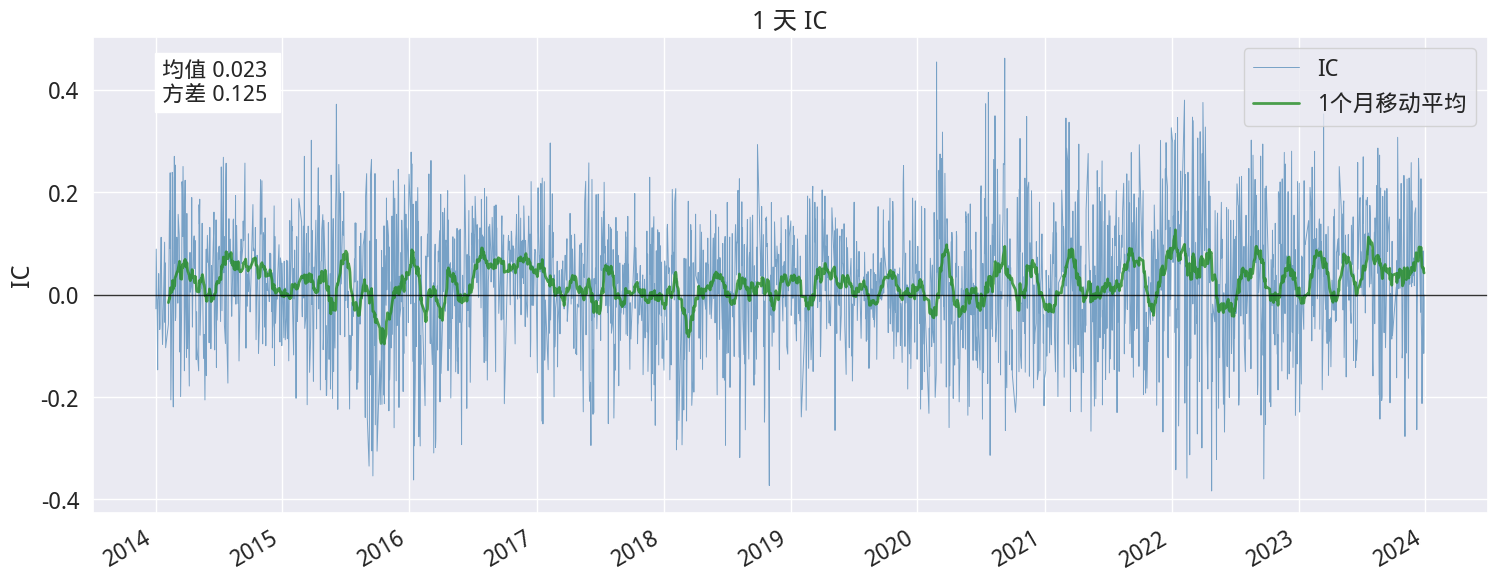

In [6]:
pcf_far.plot_ic_ts(method="rank")

从收益表现来看, 各分组收益并非严格单调, 价格均线收敛的分组表现处于各分组收益的中游水平, 而价格均线发散的分组则长期稳定跑输。价格均线发散往往对应股价大幅拉涨和砸盘, 从结果来看, 行情趋势中追高和抄底都是不建议的操作。

<Figure size 640x480 with 0 Axes>

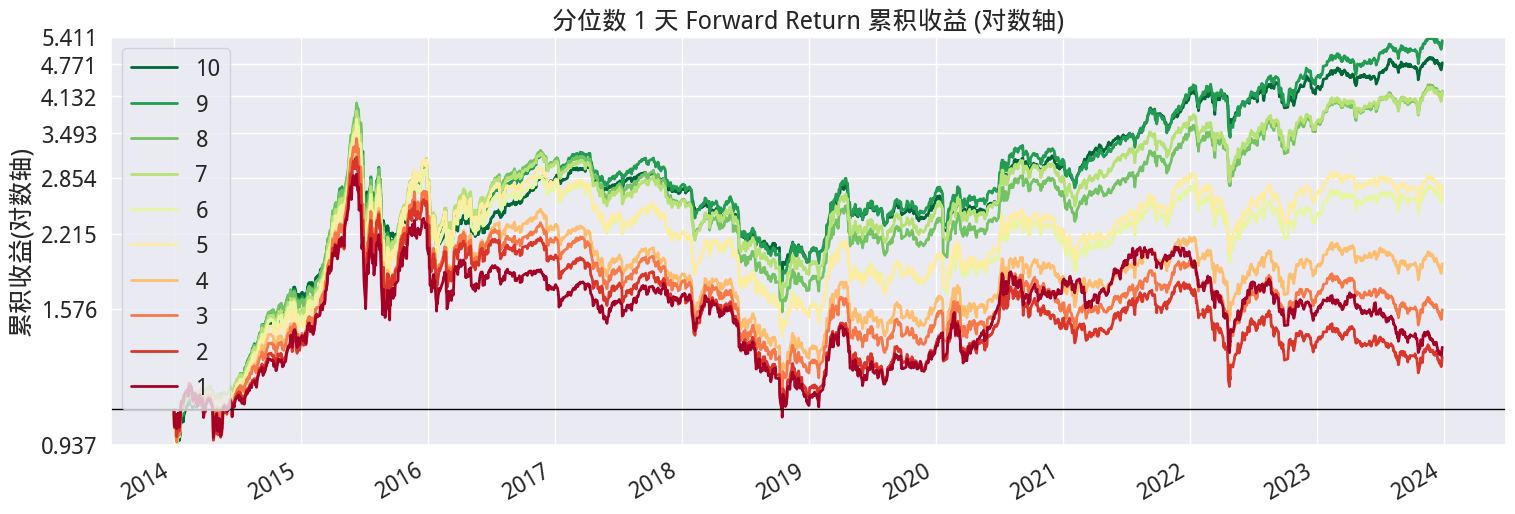

In [7]:
pcf_far.plot_cumulative_returns_by_quantile()

<Figure size 640x480 with 0 Axes>

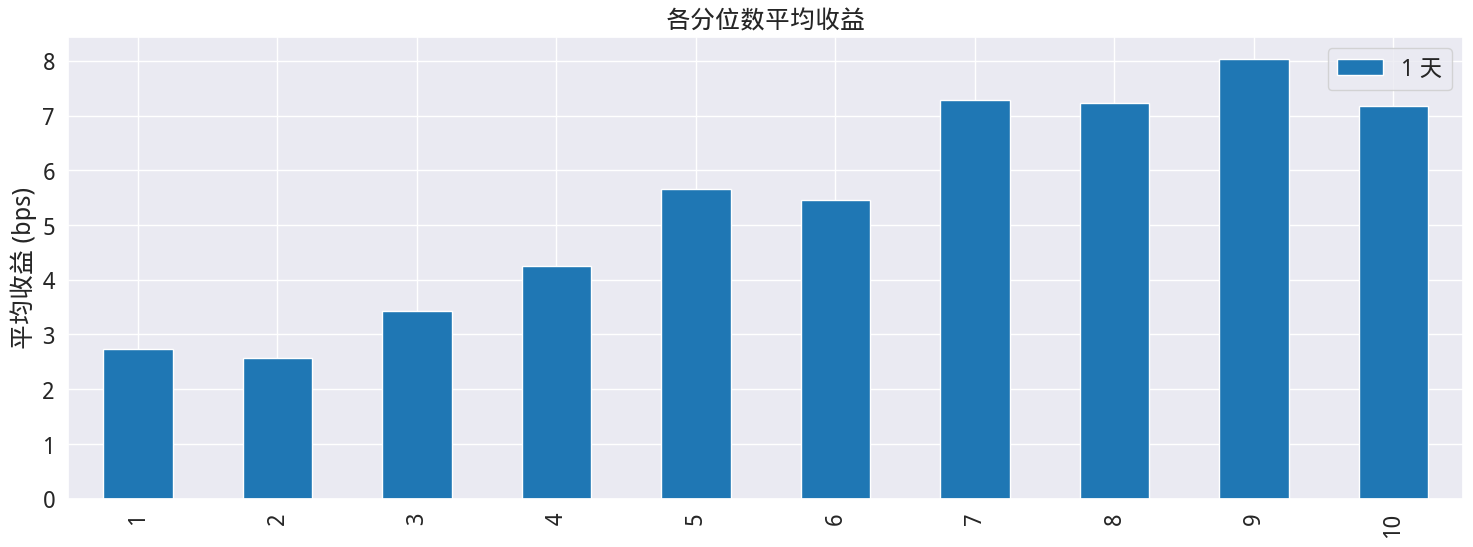

In [8]:
pcf_far.plot_quantile_returns_bar()

回到我们关切的问题, 为什么价格均线收敛的收益预测能力表现疲弱? 我们认 为主要有两点原因:

第一, 价格均线收敛时, 既可以发生在股价低位, 亦可以在股价的阶段高点。 若个股在股价低位发生价格均线收敛, 未来上涨的概率往往要高于处于阶段高点价 格均线收敛的个股。在 A 股市场, 反转易得, 动量难寻, 个股价格高低位的变化影 响了均线收敛的变盘胜率。

第二, 在市场整体处于强趋势行情的时候, 价格均线发散反而是一种强势信号,  此时在股价维度追逐动量相比博弈短期反转, 在盈亏比上具有优势, 其亦是不同市 场环境下价格收敛因子表现出现显著差异的直接影响因素。

二者因素叠加后, 价格均线收敛的选股区分度被相应弱化, 其在选股层面, 更 多作为一个变盘点的信号, 是个股选择方向的前兆, 但往上还是往下, 两者的概率 差异还处于较低水平。为此, 我们尝试引入股价当前位置高低的信息。

## 成交量的收敛与发散

前文我们探讨了股票价格均线收敛与发散所蕴含的选股能力, 但单纯的价格可 能存在欺骗性，没有成交量辅助的价格是镜中花、水中月，虚实难辨。仿照前文思 路, 我们尝试通过成交量均线的收敛与发散来刻画当前股价位置高低。

如何理解成交量的收敛与发散形态特征呢? 不同周期成交量均线的收敛发散衡 量了市场上投资者交易意愿的变化。当长短期成交量水平趋于一致时, 往往是因为 个股赚钱效应弱化, 导致投资者交易意愿下滑, 股价处于阶段底部的概率升高。因 为个股股价高涨, 行情过热时, 会吸引到市场上其他投资者的关注, 造成短期成交 量迅速放大从而超过长期的成交水平, 不同周期成交量均线呈现出发散的形态。

我们根据前文价格收敛因子(PCF)的构建方式来计算成交量收敛因子(Volume  Convergence Factor, VCF)。成交量收敛因子(VCF)全区间内RankIC均值为3.8%, 表现较好。

In [9]:
# 获取收盘价数据
volume_df: pd.DataFrame = get_ashare_data(BEGIN, END, "volume")

# 因子构建
vcf_factor: pd.DataFrame = calculate_convergence_factor(volume_df, PERIODS).loc[
    START:END
]

In [10]:
# 单因子分析
vcf_far: FactorAnalyzer = FactorAnalyzer(
    vcf_factor.stack().dropna(),
    close_df.loc[START:END],
    quantiles=10,
    periods=(1,),
)

<Figure size 640x480 with 0 Axes>

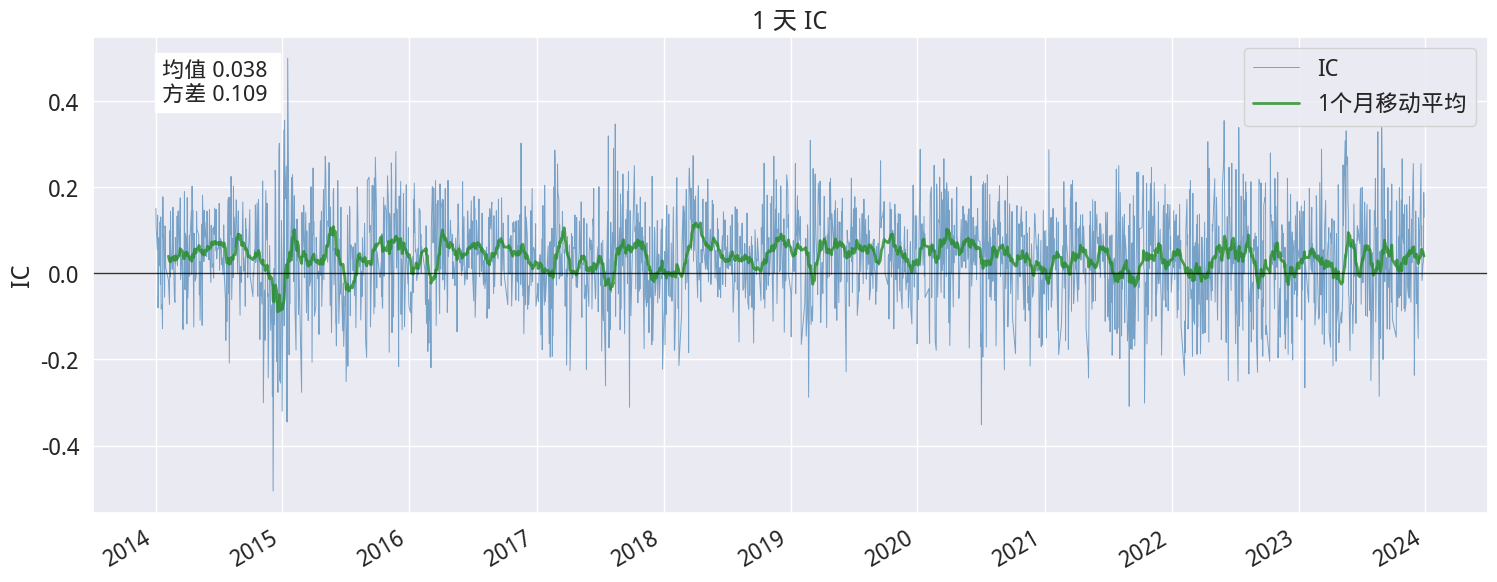

In [11]:
vcf_far.plot_ic_ts(method="rank")

成交量收敛因子 (VCF) 在全区间内分组收益单调, 但是 2021 年以来, 多空超额收益的波动有所放大。测试结果一定程度上能够说明低位缩量的个股未来上涨的 概率显著高于高位放量的个股。

<Figure size 640x480 with 0 Axes>

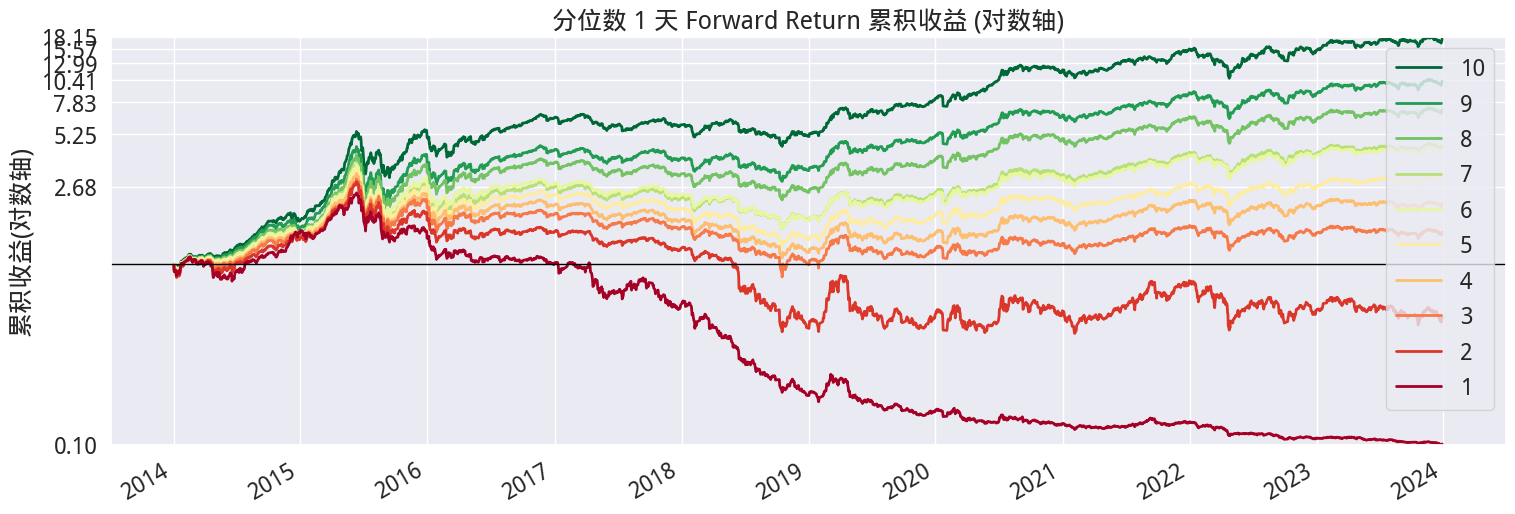

In [12]:
vcf_far.plot_cumulative_returns_by_quantile()

<Figure size 640x480 with 0 Axes>

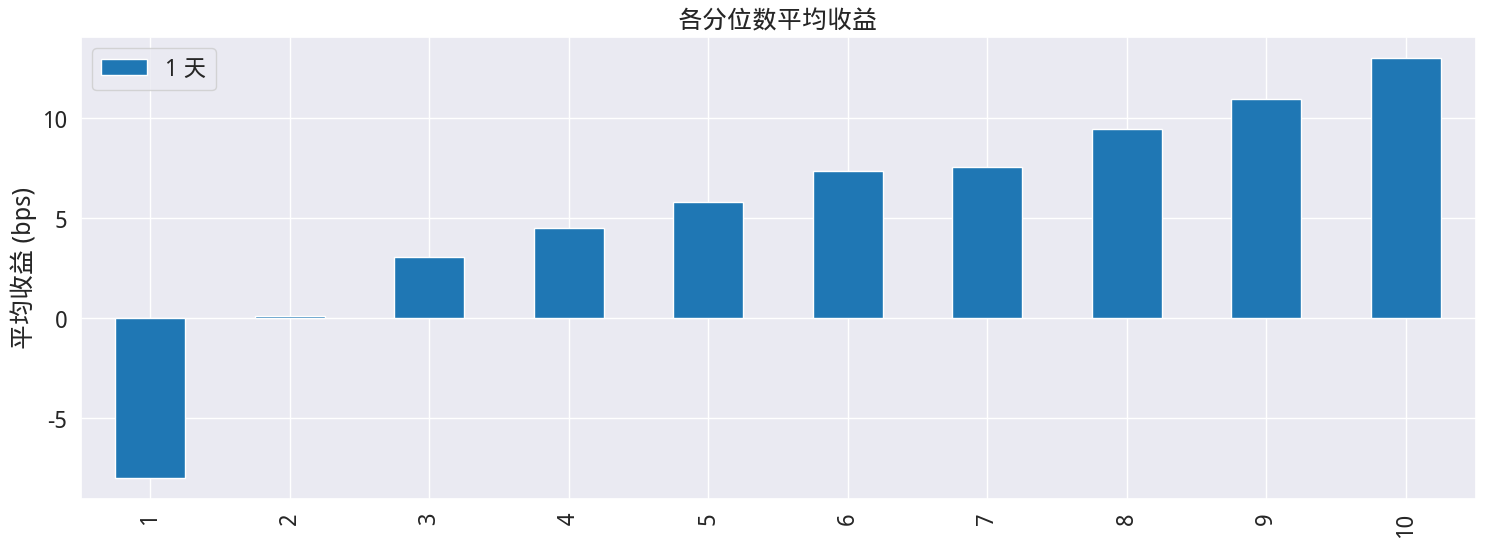

In [13]:
vcf_far.plot_quantile_returns_bar()

## 价与量的同频共振

上文中, 我们从价格均线形态出发讨论了股价面临变盘的可能, 从成交量均线 形态维度锚定了个股当前股价位置的高低水平。若将价量均线形态二者进行结合,  会发生怎样的化学反应呢?

通过将价与量进行融合, 我们希望通过价格均线收敛与否来判断个股当前时刻 是否位于变盘点前夕，通过成交量均线收敛与否来判断个股当前所处位置的高低。 如果某只个股价格和成交量均线都处于收敛状态, 则我们倾向于认为该只股票处于 阶段低位且面临变盘的可能, 未来股价向上反转的概率大幅增加。反之, 若价量均 线双发散，表明投资者在赚钱效应的吸引下，短期内大幅涌入该只个股。

我们计算了价格收敛因子 (PCF) 与成交量收敛因子 (VCF) 二者在时序上的相 关性, 根据测试结果可知, PCF 与 VCF 呈现弱相关性, 全区间均值约为10.03%, 表明价格均线收敛与成交量均线收敛蕴含着不同的信息, 可以用来进行融合。

我们将 PCF 与 VCF 在截面进行标准化后进行加总, 构建价量双收敛因子 (Price  Volume Convergence Factor, PVCF)

In [14]:
# PCF\VCF截面标准化后合成PVCF因子
pvcf_factor: pd.DataFrame = standardlize(pcf_factor) + standardlize(vcf_factor)

findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font family 'Heiti SC' not found.
findfont: Font family 'WenQuanYi Micro Hei Mono' not found.
findfont: Font family 'WenQuanYi Zen Hei Sharp' not found.
findfont: Font family 'WenQuanYi Zen Hei Mono' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font family 'Heiti SC' not found.
findfont: Font family 'WenQuanYi Micro Hei Mono' not found.
findfont: Font family 'WenQuanYi Zen Hei Sharp' not found.
findfont: Font family 'WenQuanYi Zen Hei Mono' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font 

corr均值0.1013


findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font family 'Heiti SC' not found.
findfont: Font family 'WenQuanYi Micro Hei Mono' not found.
findfont: Font family 'WenQuanYi Zen Hei Sharp' not found.
findfont: Font family 'WenQuanYi Zen Hei Mono' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font family 'Heiti SC' not found.
findfont: Font family 'WenQuanYi Micro Hei Mono' not found.
findfont: Font family 'WenQuanYi Zen Hei Sharp' not found.
findfont: Font family 'WenQuanYi Zen Hei Mono' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font 

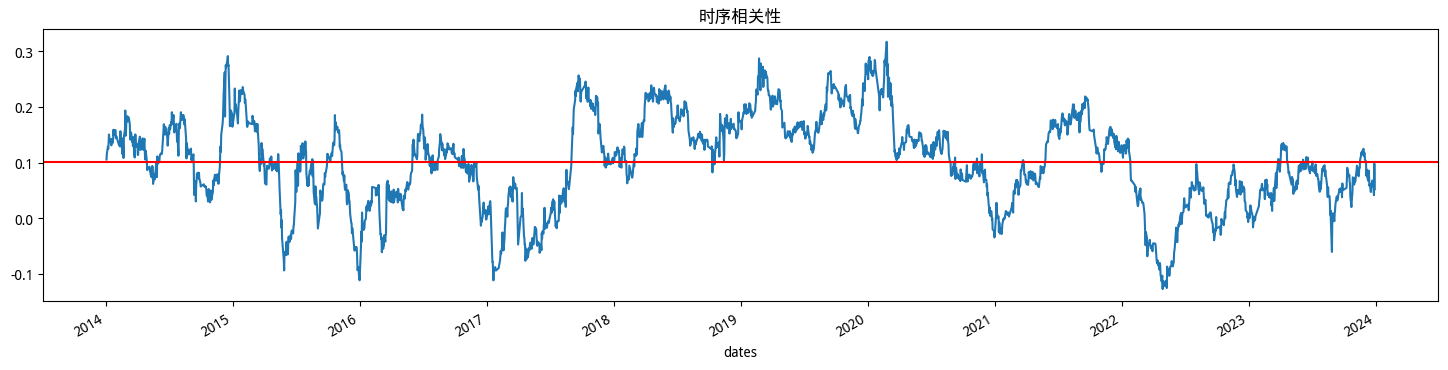

In [15]:
corr_ts: pd.Series = pcf_factor.corrwith(vcf_factor, method="spearman", axis=1)
ax = corr_ts.plot(figsize=(18, 4), title="时序相关性")
ax.axhline(corr_ts.mean(), color="r")
print(f"corr均值{corr_ts.mean():.4f}")

In [16]:
# 单因子分析
pvcf_far: FactorAnalyzer = FactorAnalyzer(
    pvcf_factor.stack().dropna(),
    close_df.loc[START:END],
    quantiles=10,
    periods=(1,),
)

我们将 PCF 与 VCF 在截面进行标准化后进行加总, 构建价量双收敛因子 (Price  Volume Convergence Factor, PVCF)。在测试期内, 价量双收敛因子 (PVCF) 相比单 一价量因子, 表现有所提升, RankIC均值为 4%

<Figure size 640x480 with 0 Axes>

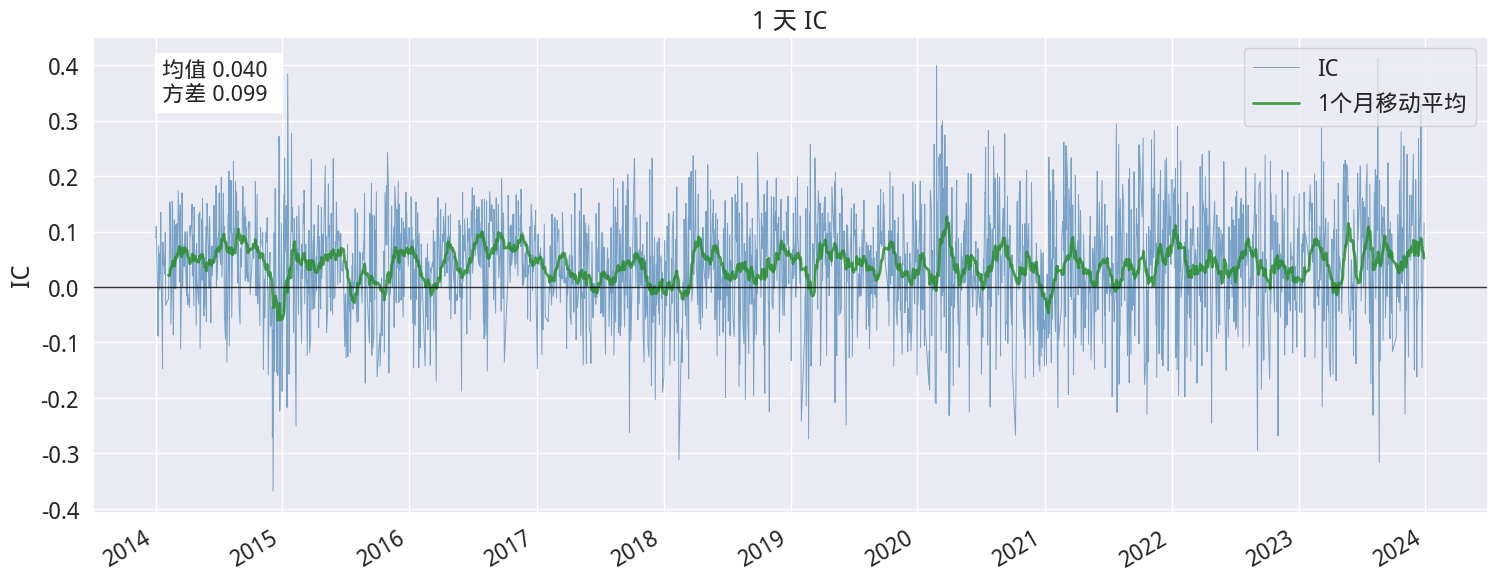

In [17]:
pvcf_far.plot_ic_ts(method="rank")

价量双收敛因子 (PVCF) 的五分组收益严格单调, 且近期超额收益走势依然稳 健, 价与量的融合有效地弥补了二者单独构建因子的不足。

<Figure size 640x480 with 0 Axes>

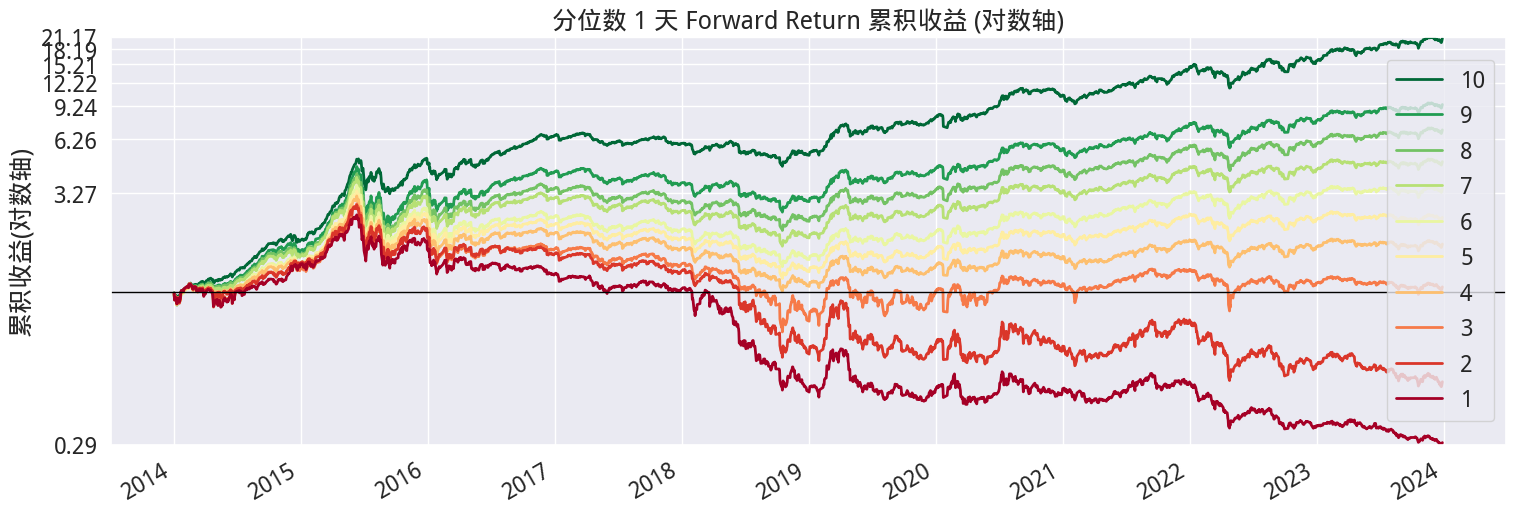

In [18]:
pvcf_far.plot_cumulative_returns_by_quantile()

<Figure size 640x480 with 0 Axes>

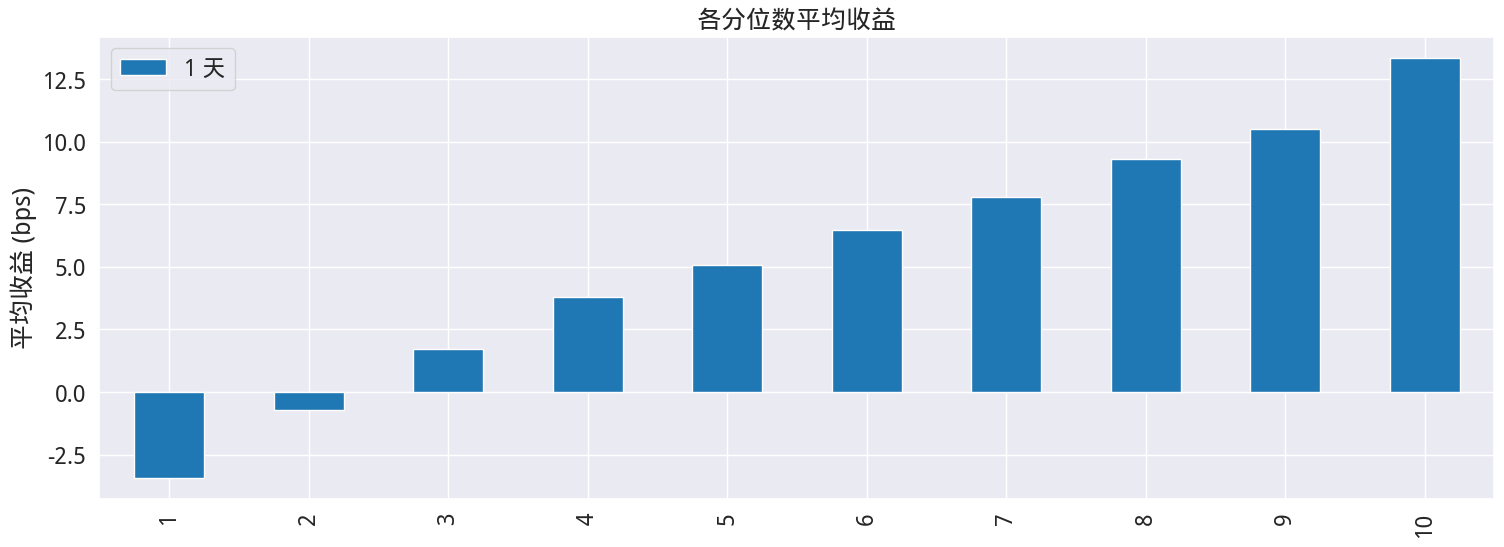

In [19]:
pvcf_far.plot_quantile_returns_bar()

# 另类均线的收敛与发散

市场中主流的交易终端软件中, 受限于页面大小, 通常仅展示个股价格和成交 量均线的相关信息, 而对于其他指标的均线覆盖和展示较少。虽然隐秘角落里的其 他指标不直观可见, 但却蕴含着重要的信息, 一如隐匿在海面之下的冰山才是冰山 的重要部分。

上文中, 我们探讨了个股价格均线和成交量均线的形态对未来股价的预测能力。 但是实际上价格与成交量的融合, 一定程度上可以用个股成交额来替代。二者的差 异在于价与量的融合, 是通过因子值相加的方式, 而成交额则直接可通过价乘以量 计算得到, 那么成交额均线收敛是否具有股票收益预测能力呢?

## 成交额收敛因子

按照前文的因子构建方式, 我们测试了成交额收敛因子 (Amount Convergence  Factor, ACF) 的表现。全区间内, 成交额收敛因子 (ACF) RankIC 均值为4.9%, 相比与融合后的价量双收敛因子 (PVCF), 效果进一步提升。

In [20]:
# 获取成交额数据
amount_df: pd.DataFrame = get_ashare_data(BEGIN, END, "amount")

In [21]:
# 计算因子
acf_factor: pd.DataFrame = calculate_convergence_factor(amount_df, PERIODS).loc[
    START:END
]

In [22]:
# 单因子分析
acf_far: FactorAnalyzer = FactorAnalyzer(
    acf_factor.stack().dropna(),
    close_df.loc[START:END],
    quantiles=10,
    periods=(1,),
)

从收益表现来看, 成交额收敛因子 (ACF) 分组收益严格单调, 多头端收益和 多空收益相比价量双收敛因子（PVCF）均有提升。究其原因, 在于我们在因子构建的过程中, 刻意保留了个股在数据上的量纲差 异, 导致低成交额个股更容易被选中, 而成交额越低的个股对应的市场关注度往往越低。再者, 均线收敛与发散分别对应低波动与高波动的过程。那么当我们选取成 交额均线收敛的个股一定程度上类似于选取低波低关注度个股, 二者长期来看具有 超额收益获取能力。

<Figure size 640x480 with 0 Axes>

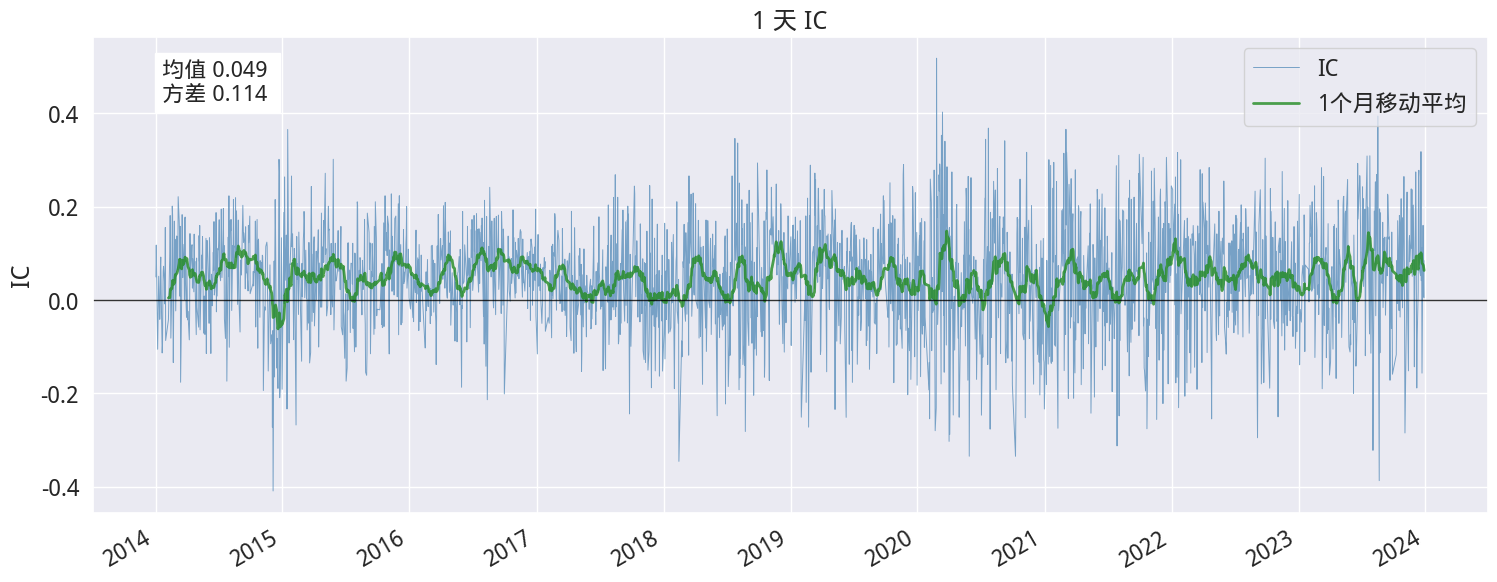

In [23]:
acf_far.plot_ic_ts(method="rank")

<Figure size 640x480 with 0 Axes>

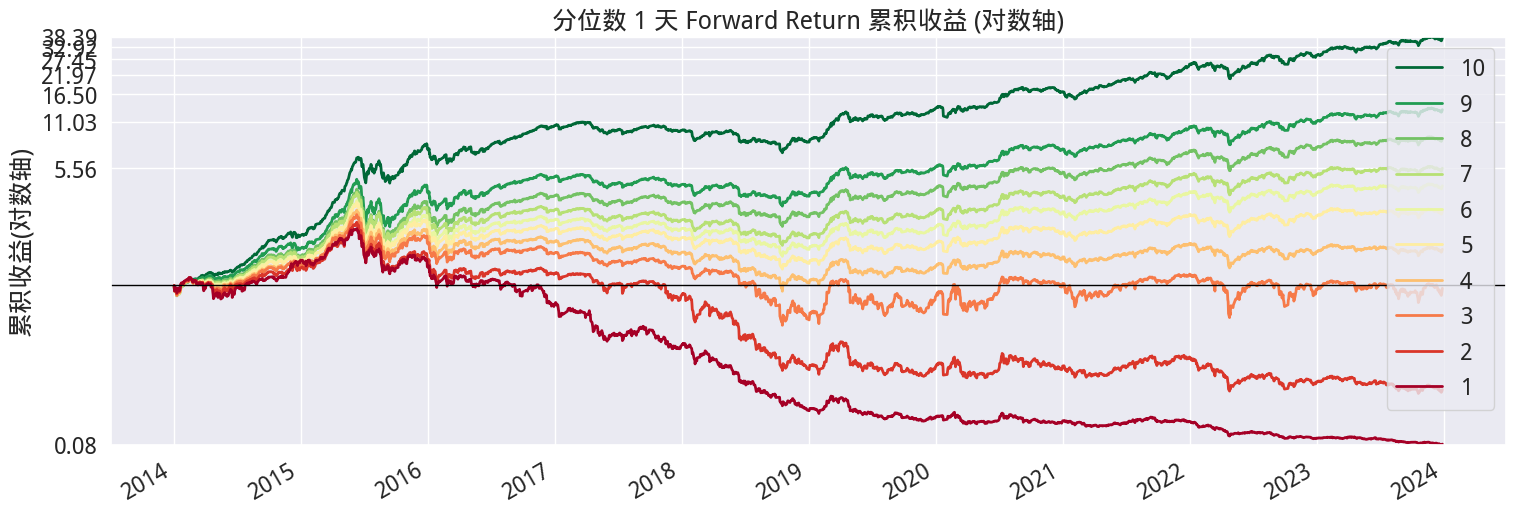

In [24]:
acf_far.plot_cumulative_returns_by_quantile()

<Figure size 640x480 with 0 Axes>

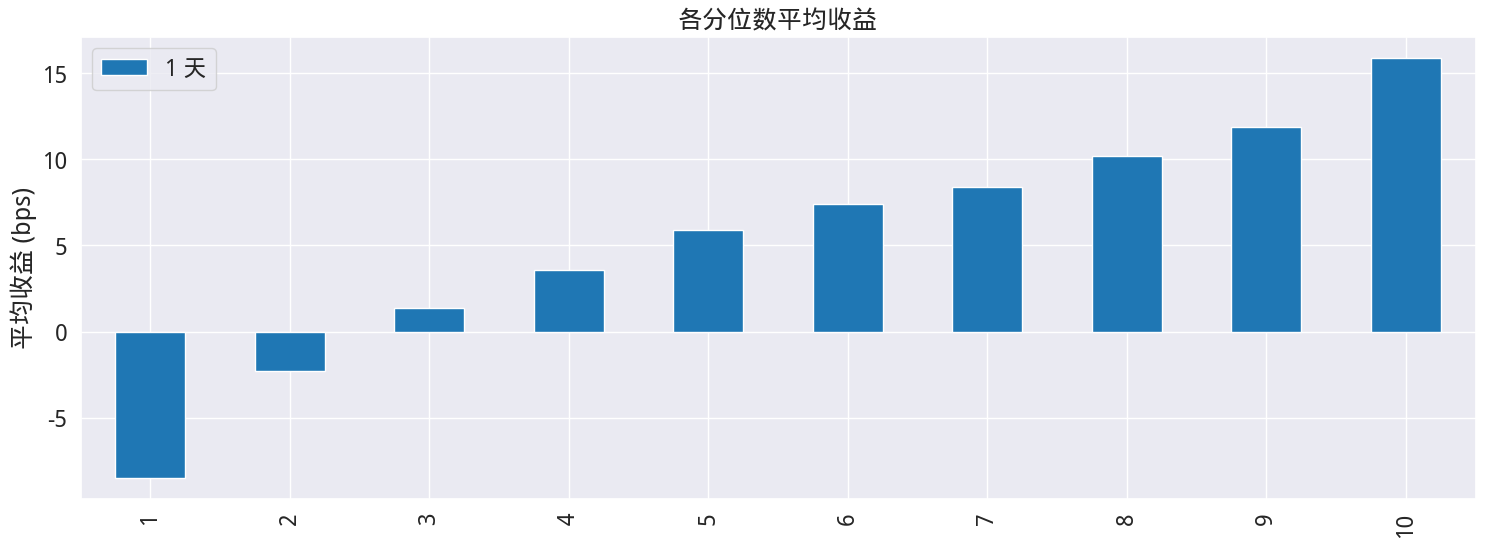

In [25]:
acf_far.plot_quantile_returns_bar()

## 换手率收敛因子

如果将成交额视为个股交易活跃度高低的绝对量值, 那么换手率便是个股交易活跃度高低的相对水平。代表活跃度绝对量级的成交额表现可圈可点, 那么剔除量 纲差异刻画交易活跃度相对水平的换手率表现又如何呢? 为此, 我们尝试从换手率均线的收敛与发散形态入手, 构建换手率收敛因子 (Turnover Rate Convergence Factor,  TRCF)。

不同个股之间的换手率虽然不存在量纲差异, 但在A股市场中大市值个股相比小市值个股天然具有更低的换手率水平, 导致我们在进行换手率收敛因子计算的时候, 等价于给予大市值个股更高的隐含权重。 成交额则恰好相反, 成交金额越大, 流通市值越高。

In [26]:
turn_df: pd.DataFrame = get_ashare_data(BEGIN, END, "turn")

In [27]:
trcf_factor: pd.DataFrame = calculate_convergence_factor(turn_df, PERIODS).loc[
    START:END
]

In [28]:
# 单因子分析
trcf_far: FactorAnalyzer = FactorAnalyzer(
    trcf_factor.stack().dropna(),
    close_df.loc[START:END],
    quantiles=10,
    periods=(1,),
)

<Figure size 640x480 with 0 Axes>

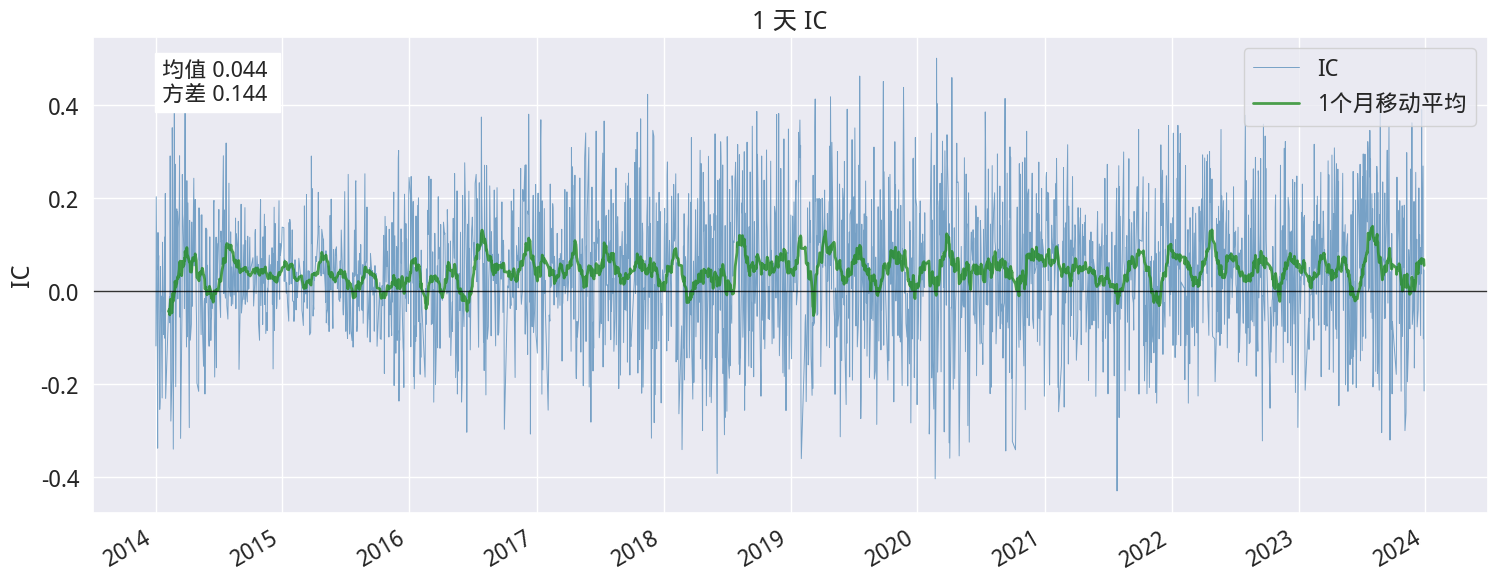

In [29]:
trcf_far.plot_ic_ts(method="rank")

从分组收益来看, 换手率收敛因子表现优异, 且超额收益率主要集中在多头端。

<Figure size 640x480 with 0 Axes>

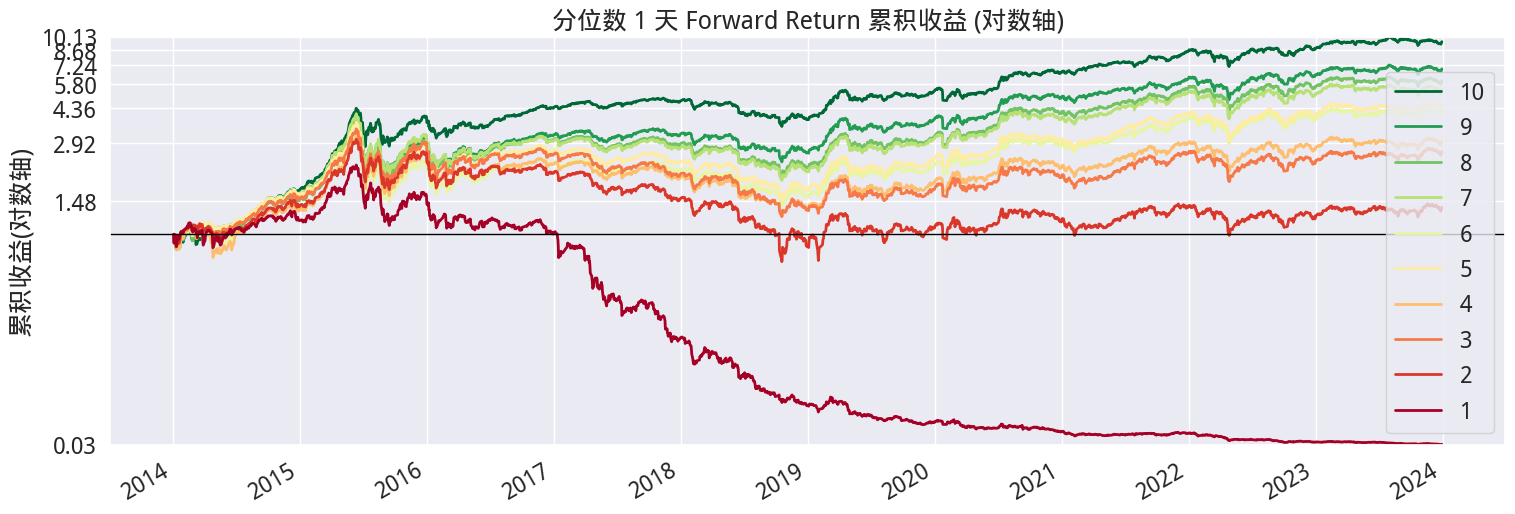

In [30]:
trcf_far.plot_cumulative_returns_by_quantile()

<Figure size 640x480 with 0 Axes>

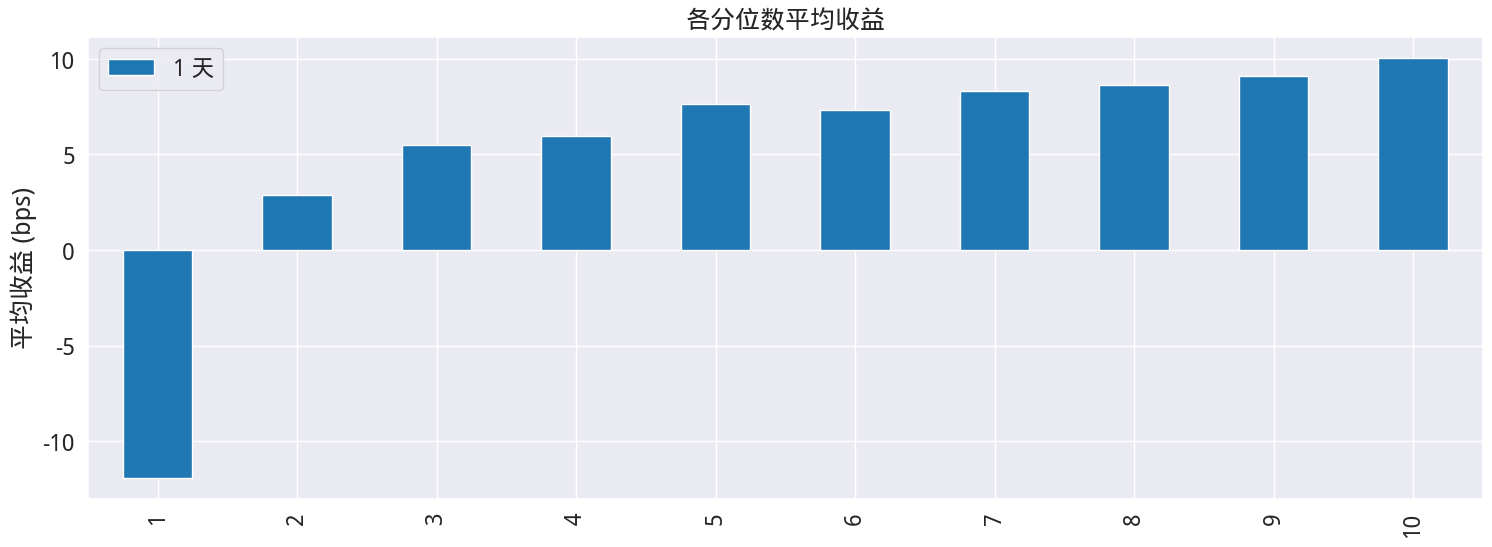

In [31]:
trcf_far.plot_quantile_returns_bar()

通过对比上述五个因子的表现可知, 合成的PVCF相比单一因子在因子预测上稍有提升, 与原研报不同的是PVCF并未受PCF的拖累, 在因子稳定性上PVCF相比VCF有小幅增强。单指标构建的ACF和TRCF相比合成的PVCF, 预测能力进一步提升, 其中ACF表现最优。

In [32]:
def plot_ic_ir_chart(far_dict: Dict):
    """
    绘制IC和IR图表。

    参数:
    far_dict (Dict): 包含多个FactorAnalysisResult对象的字典。

    返回:
    无返回值，直接显示图表。
    """
    ic: List = [far.ic["period_1"].mean() for far in far_dict.values()]
    ir: List = [
        far.ic["period_1"].mean() / far.ic["period_1"].std()
        for far in far_dict.values()
    ]

    df: pd.DataFrame = pd.DataFrame({"IC": ic, "IR": ir}, index=far_dict.keys())

    ax = df["IC"].plot(kind="bar", color="blue", label="IC")
    ax2 = ax.twinx()
    df["IR"].plot(kind="line", color="red", ax=ax2, label="IR")
    ax.figure.legend()
    plt.show()

findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font family 'Heiti SC' not found.
findfont: Font family 'WenQuanYi Micro Hei Mono' not found.
findfont: Font family 'WenQuanYi Zen Hei Sharp' not found.
findfont: Font family 'WenQuanYi Zen Hei Mono' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font family 'Heiti SC' not found.
findfont: Font family 'WenQuanYi Micro Hei Mono' not found.
findfont: Font family 'WenQuanYi Zen Hei Sharp' not found.
findfont: Font family 'WenQuanYi Zen Hei Mono' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'FangSong' not found.
findfont: Font family 'STXihei' not found.
findfont: Font family 'Hiragino Sans GB' not found.
findfont: Font 

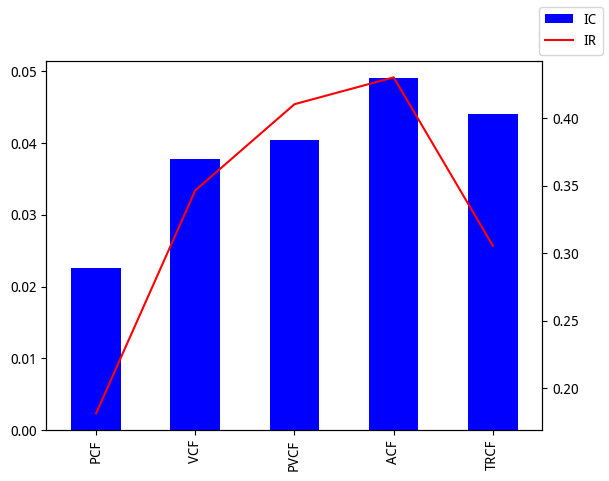

In [33]:
far_dict: Dict = {
    "PCF": pcf_far,
    "VCF": vcf_far,
    "PVCF": pvcf_far,
    "ACF": acf_far,
    "TRCF": trcf_far,
}

plot_ic_ir_chart(far_dict)